# Notebook 01 - Dataset Analysis & Deterministic Split Generation

This notebook scans the prepared dataset and generates the official dataset splits used for all future experiments.

First, the dataset is indexed by scanning the `data/prepared/` directory and collecting the filepath and class label for every image. Using this information, the dataset is split into training, validation, and test sets using a **stratified deterministic split** (80% train, 10% validation, 10% test) with a fixed random seed.

The stratified split ensures that the class distribution remains consistent across all splits, which is essential for fair model evaluation and reproducible experiments.

The generated splits are saved as CSV manifests in `data/splits/split_v1/`, along with a `classes.json` file defining the mapping between class names and numeric labels. The notebook also produces dataset statistics and visualizations, including class distribution plots and a JSON summary report, and logs the dataset information to MLflow for experiment tracking.

These artifacts form the **official dataset split version** that all models in later phases will use.

In [4]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import mlflow

PROJECT_ROOT = Path.cwd().parent
DATA_PREPARED_DIR = PROJECT_ROOT / "data" / "prepared"
SPLIT_DIR = PROJECT_ROOT / "data" / "splits" / "split_v1"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
METRICS_DIR = REPORTS_DIR / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["cats", "dogs", "wildlife"]
CLASSES_TO_IDX = {"cats": 0, "dogs": 1, "wildlife": 2}

print("Prepared:", DATA_PREPARED_DIR)
print("Split dir:", SPLIT_DIR)

f:\Projects\AnimalClassification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Prepared: f:\Projects\AnimalClassification\data\prepared
Split dir: f:\Projects\AnimalClassification\data\splits\split_v1


In [5]:
import sys

sys.path.append(str(PROJECT_ROOT))

from src.data.split_generator import scan_prepared_dataset, SplitConfig, make_stratified_splits, write_splits, validate_splits

df = scan_prepared_dataset(DATA_PREPARED_DIR, CLASSES)
df.head(), df["label"].value_counts()

(                                            filepath label
 0  f:/Projects/AnimalClassification/data/prepared...  cats
 1  f:/Projects/AnimalClassification/data/prepared...  cats
 2  f:/Projects/AnimalClassification/data/prepared...  cats
 3  f:/Projects/AnimalClassification/data/prepared...  cats
 4  f:/Projects/AnimalClassification/data/prepared...  cats,
 label
 cats        23693
 dogs        22894
 wildlife    16072
 Name: count, dtype: int64)

In [6]:
cfg = SplitConfig(seed=42, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1)
splits = make_stratified_splits(df, cfg)

{k: v.shape for k, v in splits.items()}

{'train': (50127, 2), 'val': (6266, 2), 'test': (6266, 2)}

In [7]:
ratio_report = validate_splits(df, splits, CLASSES)
ratio_report

{'original': {'cats': 0.3781260473355783,
  'dogs': 0.3653744873042979,
  'wildlife': 0.25649946536012386},
 'train': {'cats': 0.3781195762762583,
  'dogs': 0.36537195523370636,
  'wildlife': 0.25650846849003534},
 'val': {'cats': 0.3780721353335461,
  'dogs': 0.3654644111075646,
  'wildlife': 0.2564634535588892},
 'test': {'cats': 0.3782317267794446,
  'dogs': 0.3653048196616661,
  'wildlife': 0.2564634535588892}}

In [8]:
write_splits(splits, SPLIT_DIR, CLASSES_TO_IDX)

(SPLIT_DIR / "train.csv").exists(), (SPLIT_DIR / "classes.json").exists()

(True, True)

F:\Temp\ipykernel_20716\1928166401.py:18: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  ax = plot_df.plot(kind="bar", figsize=(10, 5))


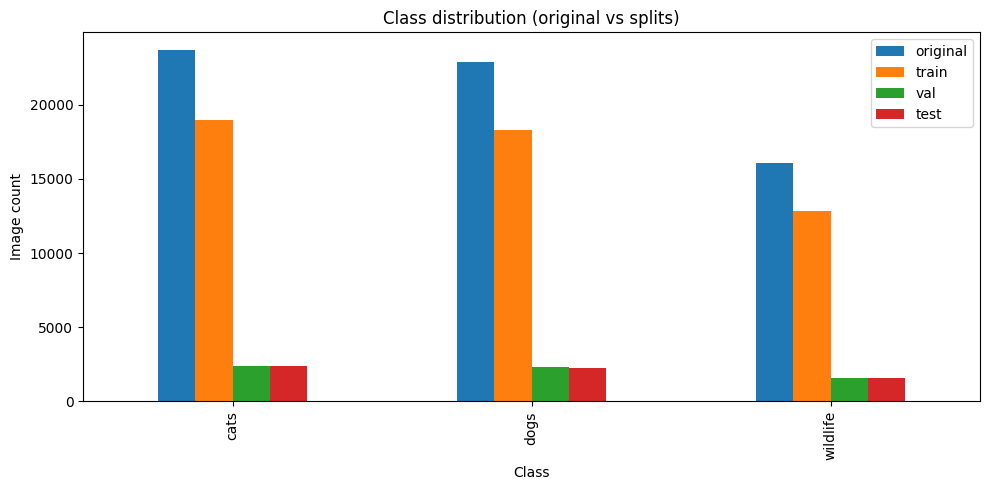

WindowsPath('f:/Projects/AnimalClassification/reports/figures/class_distribution.png')

In [9]:
def counts_for(dfx: pd.DataFrame):
    return dfx["label"].value_counts().reindex(CLASSES, fill_value=0)

original_counts = counts_for(df)
train_counts = counts_for(splits["train"])
val_counts = counts_for(splits["val"])
test_counts = counts_for(splits["test"])

plot_df = pd.DataFrame(
    {
        "original": original_counts,
        "train": train_counts,
        "val": val_counts,
        "test": test_counts,
    }
)

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("Class distribution (original vs splits)")
ax.set_xlabel("Class")
ax.set_ylabel("Image count")
plt.tight_layout()

out_path = FIGURES_DIR / "class_distribution.png"
plt.savefig(out_path, dpi=150)
plt.show()

out_path

In [10]:
summary = {
    "dataset_total": int(len(df)),
    "counts_original": original_counts.to_dict(),
    "counts_train": train_counts.to_dict(),
    "counts_val": val_counts.to_dict(),
    "counts_test": test_counts.to_dict(),
    "ratios": ratio_report,
    "split_version": "split_v1",
    "seed": 42,
    "paths": {
        "prepared_dir": str(DATA_PREPARED_DIR.as_posix()),
        "split_dir": str(SPLIT_DIR.as_posix()),
    },
}

out_json = METRICS_DIR / "data_summary_split_v1.json"
out_json.write_text(json.dumps(summary, indent=2), encoding="utf-8")

out_json

WindowsPath('f:/Projects/AnimalClassification/reports/metrics/data_summary_split_v1.json')

In [11]:
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("AnimalClassification")

with mlflow.start_run(run_name="phase1_split_v1"):
    mlflow.log_params(
        {
            "split_version": "split_v1",
            "seed": 42,
            "train_ratio": cfg.train_ratio,
            "val_ratio": cfg.val_ratio,
            "test_ratio": cfg.test_ratio,
            "image_size": 224,
        }
    )

    mlflow.log_metrics(
        {
            "dataset_total": float(len(df)),
            "train_size": float(len(splits["train"])),
            "val_size": float(len(splits["val"])),
            "test_size": float(len(splits["test"])),
        }
    )

    for c in CLASSES:
        mlflow.log_metrics(
            {
                f"count_original_{c}": float(original_counts[c]),
                f"count_train_{c}": float(train_counts[c]),
                f"count_val_{c}": float(val_counts[c]),
                f"count_test_{c}": float(test_counts[c]),
            }
        )

    mlflow.log_artifact(str(out_json))
    mlflow.log_artifact(str(FIGURES_DIR / "class_distribution.png"))

"Logged to MLflow"

f:\Projects\AnimalClassification\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/04 16:11:26 INFO mlflow.tracking.fluent: Experiment with name 'AnimalClassification' does not exist. Creating a new experiment.


'Logged to MLflow'